In [16]:
# Cell 1 — imports and load data
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

quakes = pd.read_parquet("../data/raw/usgs_2016_2026.parquet")
gps    = pd.read_parquet("../data/raw/gps_raw.parquet")
faults = gpd.read_file("../data/raw/san_andreas_faults.geojson")

print(f"Quakes: {len(quakes):,} events")
print(f"GPS: {gps['station_code'].nunique()} stations, {len(gps):,} records")
print(f"Faults: {len(faults)} segments")

Quakes: 115,828 events
GPS: 8 stations, 68,378 records
Faults: 8042 segments


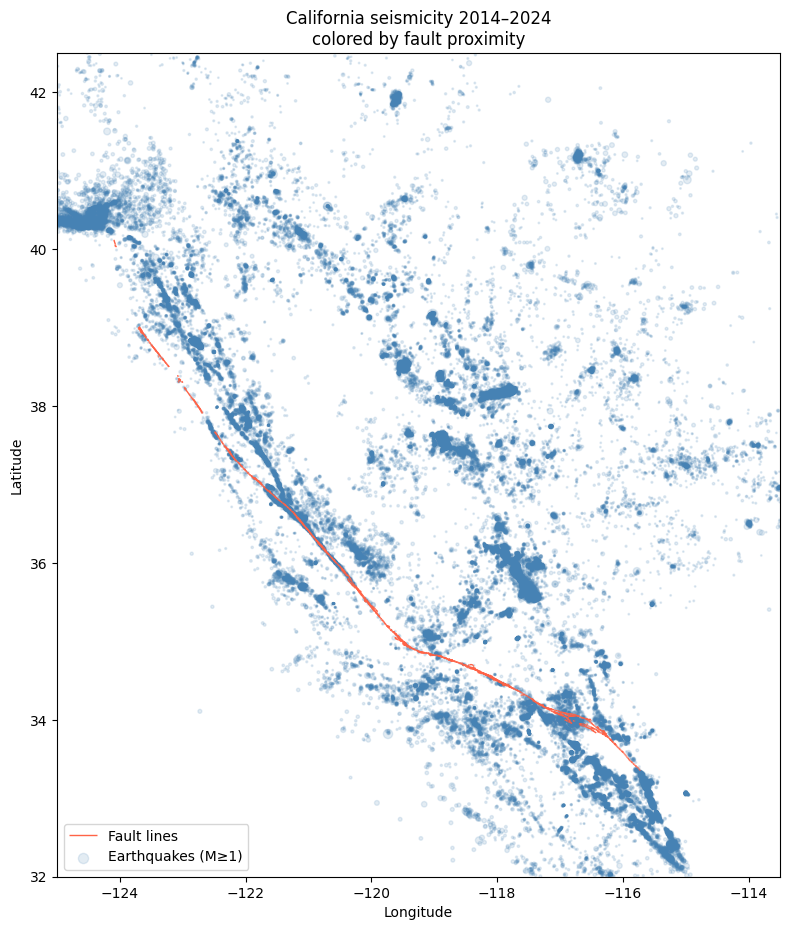

In [17]:
# Cell 2 — PLOT 1: Spatial overview
# This is your most important sanity check. Earthquakes should cluster
# tightly along fault lines. Scattered random-looking points = something wrong.

fig, ax = plt.subplots(figsize=(8, 12))

faults.plot(ax=ax, color="tomato", linewidth=1.0, zorder=2, label="Fault lines")

# Plot quakes sized by magnitude — M3 should be a dot, M6 should be visible
sizes = (quakes["magnitude"] ** 3) * 0.3
ax.scatter(
    quakes["longitude"], quakes["latitude"],
    s=sizes, alpha=0.15, color="steelblue",
    zorder=1, label="Earthquakes (M≥1)"
)

# Add GPS station locations
station_locs = gps.groupby("station_code").first().reset_index()
# Note: we'd need to add lat/lon to our GPS fetch for this —
# for now, mark this as a TODO and add station coords manually or from metadata
# station_locs shown as triangles when available

ax.set_xlim(-125, -113.5)
ax.set_ylim(32, 42.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("California seismicity 2014–2024\ncolored by fault proximity")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plot_spatial_overview.png", dpi=150)
plt.show()

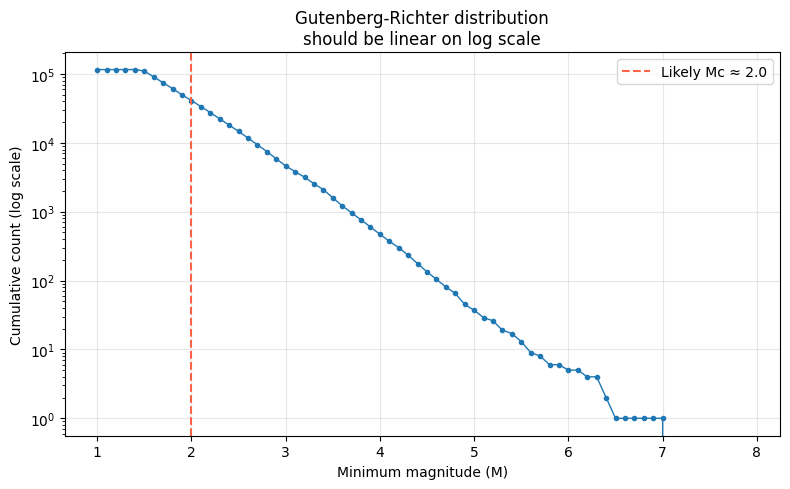

In [18]:
# Cell 3 — PLOT 2: Magnitude-frequency distribution (Gutenberg-Richter check)
# This is a fundamental law of seismology: on a log scale, magnitude vs
# count should be roughly linear. A kink in the line tells you where the
# catalog becomes "complete" — below that magnitude, not all quakes are recorded.
# Your modeling should only use quakes above the completeness threshold.

fig, ax = plt.subplots(figsize=(8, 5))

mag_bins = np.arange(1.0, 8.0, 0.1)
counts = []
for m in mag_bins:
    counts.append((quakes["magnitude"] >= m).sum())

ax.semilogy(mag_bins, counts, 'o-', markersize=3, linewidth=1)
ax.set_xlabel("Minimum magnitude (M)")
ax.set_ylabel("Cumulative count (log scale)")
ax.set_title("Gutenberg-Richter distribution\nshould be linear on log scale")
ax.grid(True, alpha=0.3)

# The 'kink' where the line bends upward marks your completeness magnitude
# Mark Mc visually — look for where linearity breaks down
ax.axvline(x=2.0, color="tomato", linestyle="--", label="Likely Mc ≈ 2.0")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plot_gutenberg_richter.png", dpi=150)
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_18024\2813575108.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quakes["year_month"] = quakes["time"].dt.to_period("M")


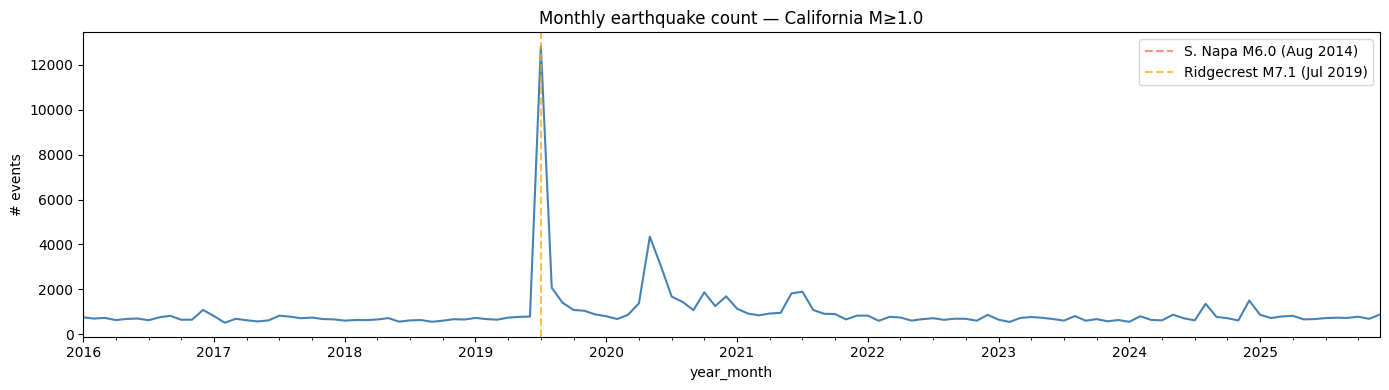

In [19]:
# Cell 4 — PLOT 3: Monthly seismicity rate
# Looking for: continuous coverage, aftershock spikes after major quakes
# (Ridgecrest 2019, South Napa 2014 should be visible as spikes)

quakes["year_month"] = quakes["time"].dt.to_period("M")
monthly = quakes.groupby("year_month").size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, kind="line", color="steelblue")
ax.set_title("Monthly earthquake count — California M≥1.0")
ax.set_ylabel("# events")

# Annotate known major events
ax.axvline("2014-08", color="tomato", alpha=0.7, linestyle="--", label="S. Napa M6.0 (Aug 2014)")
ax.axvline("2019-07", color="orange", alpha=0.7, linestyle="--", label="Ridgecrest M7.1 (Jul 2019)")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plot_monthly_seismicity.png", dpi=150)
plt.show()

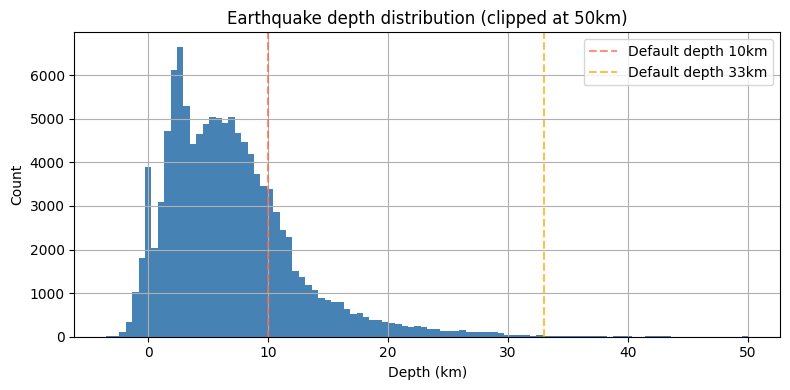

In [20]:
# Cell 5 — PLOT 4: Depth distribution
# California crustal earthquakes should mostly be 0–20km.
# Spikes at exactly 10.0 and 33.0 = placeholder depths (unknown).
# Very deep events (>50km) are subduction-related and behave differently.

fig, ax = plt.subplots(figsize=(8, 4))
quakes["depth_km"].clip(upper=50).hist(bins=100, ax=ax, color="steelblue", edgecolor="none")
ax.axvline(x=10, color="tomato", linestyle="--", alpha=0.7, label="Default depth 10km")
ax.axvline(x=33, color="orange", linestyle="--", alpha=0.7, label="Default depth 33km")
ax.set_xlabel("Depth (km)")
ax.set_ylabel("Count")
ax.set_title("Earthquake depth distribution (clipped at 50km)")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plot_depth_distribution.png", dpi=150)
plt.show()

In [21]:
import pandas as pd
gps_check = pd.read_parquet("../data/raw/gps_raw.parquet")
print(gps_check.columns.tolist())
print(gps_check.shape)


['date', 'north_mm', 'east_mm', 'up_mm', 'north_sig', 'east_sig', 'up_sig', 'station_code', 'station_name']
(68378, 9)


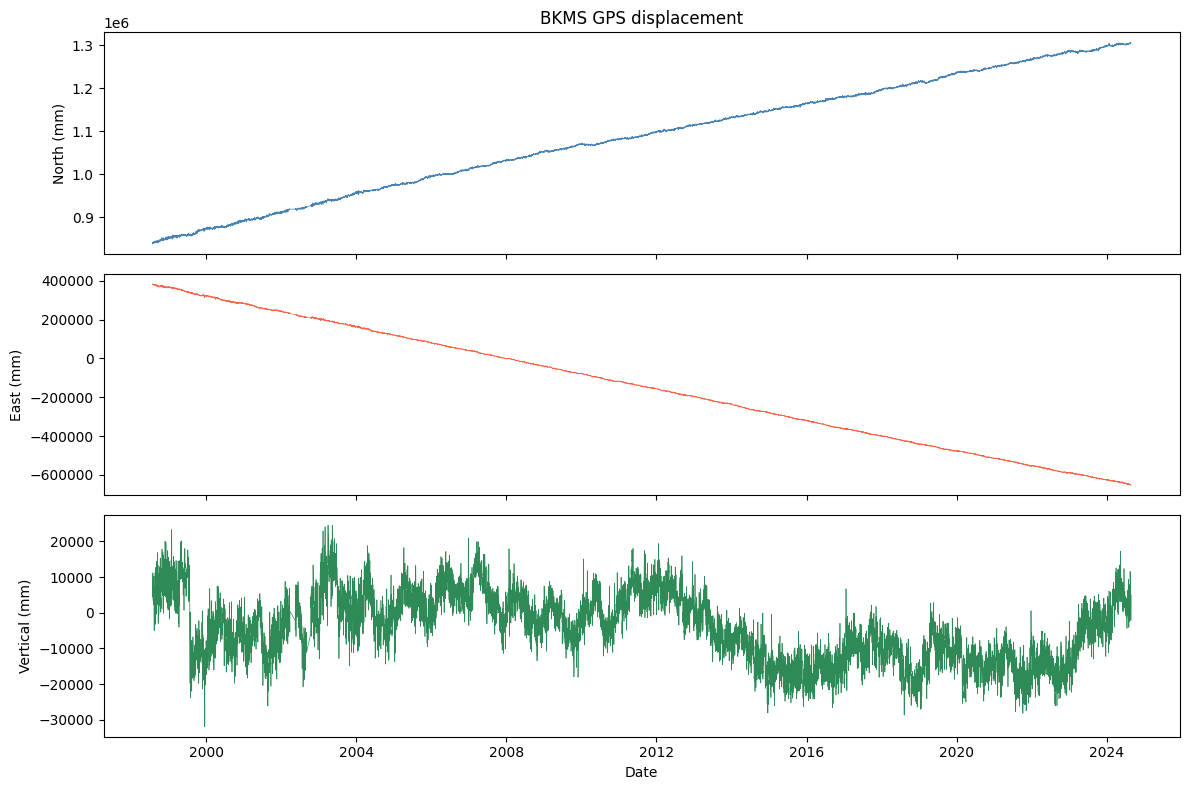

In [22]:
# Cell 6 — PLOT 5: GPS displacement time series
# Pick one station and plot its north and east displacement over time.
# You should see a clear linear trend (steady plate motion) 
# possibly with jumps at major earthquake times (coseismic offsets).
# The slope of that trend is what becomes your strain rate feature in week 2.

station = "BKMS"  # Parkfield — very active, great test case
s = gps[gps["station_code"] == station].sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(s["date"], s["north_mm"] * 1000, linewidth=0.5, color="steelblue")
axes[0].set_ylabel("North (mm)")
axes[0].set_title(f"{station} GPS displacement")

axes[1].plot(s["date"], s["east_mm"] * 1000, linewidth=0.5, color="tomato")
axes[1].set_ylabel("East (mm)")

axes[2].plot(s["date"], s["up_mm"] * 1000, linewidth=0.5, color="seagreen")
axes[2].set_ylabel("Vertical (mm)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig(f"../notebooks/plot_gps_{station}.png", dpi=150)
plt.show()

In [23]:
# Cell 7 — Summary stats you should record in your README
print("=== Week 1 Data Summary ===")
print(f"Earthquakes: {len(quakes):,} events, {quakes['time'].min().date()} to {quakes['time'].max().date()}")
print(f"Magnitude range: M{quakes['magnitude'].min():.1f} to M{quakes['magnitude'].max():.1f}")
print(f"GPS stations: {gps['station_code'].nunique()}")
print(f"GPS date range: {gps['date'].min().date()} to {gps['date'].max().date()}")
print(f"Fault segments: {len(faults)}")
print(f"\nCompleteness magnitude (Mc): ~2.0 (based on G-R plot)")
print(f"Placeholder depths: {(quakes['depth_km'].isin([10.0, 33.0])).sum():,} events — consider filtering")

=== Week 1 Data Summary ===
Earthquakes: 115,828 events, 2016-01-01 to 2025-12-31
Magnitude range: M1.5 to M7.1
GPS stations: 8
GPS date range: 1994-01-11 to 2024-08-24
Fault segments: 8042

Completeness magnitude (Mc): ~2.0 (based on G-R plot)
Placeholder depths: 255 events — consider filtering
